# ARIM-Academy：　基礎編　Scikit-learn（分類モデル）

**対象読者：** Python基礎文法を理解している方。`Scikit-learn-2_ML.ipynb`・`Scikit-learn-4_ML.ipynb`（回帰予測編）を先に学習していれば、train/testの分割やモデル構築の流れが共通していることが分かりやすくなります。

**前提知識：** 訓練/テストデータの分割、標準化、決定係数（回帰の場合）は既習として説明を省略します。本編で新しく登場する**分類（Classification）**特有の話題（正解率・混同行列・適合率・再現率）と、**欠損値の除去（`dropna()`）**は初出として説明します。

**動作環境：** Python 3.10以降 / pandas 2.x / numpy 1.26以降 / matplotlib 3.8以降 / seaborn 0.12以降 / scikit-learn 1.2以降。Google Colabの標準環境であれば満たされます。

**版・ライセンス：** 本ノートブックのコード部分はMITライセンスで提供します。

---

## 本編の目標

本演習では**『茶の元素分析データセット』**を用いて**教師あり学習**の分類技術を学びます。このデータセットには、4種類の茶葉（ブラックセイロン、ブラックトルコ、グリーンセイロン、グリーントルコ）の元素分析データに加え、抽出条件（**抽出濃度・抽出時間**）の情報も含まれています。

> **重要な訂正：** 本編で扱う決定木・ランダムフォレスト・サポートベクターマシンは、いずれも茶葉の品種ラベル（正解）を使ってモデルを学習させる**教師あり学習（Supervised Learning）**です。次のノートブック（`Scikit-learn-6.ipynb`）で扱う次元削減・クラスタリングは、ラベルを使わない**教師なし学習（Unsupervised Learning）**であり、両者は明確に区別されます。

> **前編からの更新：** 元素分析値だけを使ったクラスタリング（教師なし学習、`Scikit-learn-6_PCA_Clustering.ipynb`）では、品種による違いが「抽出濃度・抽出時間による溶出量の差」に隠れてしまい、うまく分離できないことが分かりました。そこで本編では、実際の抽出条件（`Concentration`：抽出濃度、`time`：抽出時間）を含んだデータセットを使用します。

### 本編における内容　`（　）内は本ノートブックのコードでの実施範囲`
* **データ前処理**（実施：欠損値の除去）: 元データには、測定条件が記録されていない欠損行が含まれています。`dropna()`で除去してから分析します。
* **データの可視化と解釈**（実施：ペアプロット）: 散布図やペアプロットを用いて、特徴量の分布や相関関係を視覚的に把握します。
* **分類アルゴリズムの実装**（実施：決定木・ランダムフォレスト・サポートベクターマシンの3モデル、説明変数は9元素＋抽出濃度＋抽出時間の計11個）: それぞれの特徴を理解します。ロジスティック回帰・k近傍法・ニューラルネットワークは、後述の「モデル選択」で紹介はしますが実装しません。
* **モデル評価**（実施：正解率、混同行列、適合率・再現率・F1スコア）: モデルの予測結果と正解ラベルを比較し、性能を評価する方法を習得します。
---

## データセット

**『茶の元素分析データセット』**は、ブラックセイロン(BC)、ブラックトルコ(BT)、グリーンセイロン(GC)、グリーントルコ(GT)の4種類の茶葉について、3つの抽出濃度（1%、2%、3%）×7つの抽出時間（2, 5, 10, 20, 30, 45, 60分）で抽出した液体の元素分析データです（各条件2反復、4品種×3濃度×7時間×2反復＝168件）。誘導結合プラズマ発光分光分析法（ICP-OES）で分析された元素は、Al, Ca, Cu, Fe, K, Mg, Mn, Na, Znの9種類です。[1]

[1] Durmus, Y., Atasoy, A.D. & Atasoy, A.F. Mathematical optimization of multilinear and artificial neural network regressions for mineral composition of different tea types infusions. Sci Rep 14, 18285 (2024). https://doi.org/10.1038/s41598-024-69149-1

> **本データセットについての注意：** 本ノートブックのデータは、上記論文の実験データをもとに、Python講義用に整理した9元素＋抽出条件の抽出結果です。CSVファイルには、抽出条件が記録されていない79件の欠損行が含まれています。これらは分析前に`dropna()`で除去します。

### 教材への接続
Google Colab環境でこのノートブックを実行する場合は、次のセルを実行してください。（<font color="red">ローカル環境などGoogle Colabを使わない場合は不要です</font>）

In [ ]:
! pip install matplotlib_fontja
!git clone https://github.com/ARIM-ACADEMY-2026/Advanced_Tutorial_1_scikit-learn.git
%cd Advanced_Tutorial_1_scikit-learn

# 1. データセットの読み込みと前処理

### ライブラリのインポート
カリキュラムで扱うpythonのライブラリを`import`文でロードします。機械学習のライブラリであるscikit-learnは後半でimportします。

In [1]:
#ライブラリ
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib_fontja
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### サンプルファイルの読み込み
pandasライブラリの`read_csv()`はcsvファイルを読み込むメソッドであり、指定したファイルを読み込みます。ここでは[data]フォルダーに格納されている`tea_data_2.csv`のファイルをデータフレームとして読み込み、そのデータフレームは`df`という変数に格納します。

In [2]:
#データセットの読み込み
df=pd.read_csv("data/tea_data_2.csv")
df

,Al,Ca,Cu,Fe,K,Mg,Mn,Na,Zn,Concentration,time,tea
0,3.297,4.356,0.031290,0.067,99.06,3.531,1.455,0.541,0.131,1%,2,BT
1,4.267,4.118,0.031290,0.079,106.50,3.378,1.542,0.603,0.126,1%,2,BT
2,4.088,4.763,0.033370,0.084,114.00,4.763,1.838,1.058,0.156,1%,5,BT
3,4.338,4.556,0.033370,0.091,122.60,5.005,2.269,0.958,0.162,1%,5,BT
4,4.732,5.138,0.035514,0.110,132.40,5.626,2.998,1.510,0.165,1%,10,BT
...,...,...,...,...,...,...,...,...,...,...,...,...
163,16.690,8.895,0.153000,0.236,323.40,20.450,10.420,6.360,0.335,3%,30,GC
164,17.620,8.909,0.177000,0.261,334.20,23.486,11.330,7.133,0.351,3%,45,GC
165,17.920,9.056,0.180000,0.266,332.30,22.840,11.290,7.609,0.358,3%,45,GC
166,17.820,9.128,0.175000,0.273,367.30,24.560,12.110,8.537,0.372,3%,60,GC


# 2. データの俯瞰（探索的データ分析）

### ①概要統計
元素分析で観測された9つの元素成分に加え、抽出時間（`time`）の概要統計を出力します（`Concentration`は文字列のカテゴリ変数のため`describe()`の対象外です）。

In [4]:
#概要統計
df.describe()

,Al,Ca,Cu,Fe,K,Mg,Mn,Na,Zn,time
count,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000,168.000000
mean,8.362315,6.047183,0.064047,0.140224,241.854405,14.455274,5.501926,3.350494,0.249317,24.571429
std,5.168040,1.294278,0.034462,0.060822,106.663262,7.863688,3.373980,1.646577,0.091466,20.158822
min,1.933000,3.792000,0.021600,0.049743,59.480000,3.002000,0.785000,0.541000,0.089000,2.000000
25%,4.282000,5.093500,0.038274,0.089000,157.275000,8.183250,3.238000,2.009750,0.175750,5.000000
50%,6.230000,6.029750,0.056000,0.136000,229.550000,13.755000,4.434500,3.092000,0.236500,20.000000
75%,11.692500,6.879750,0.082000,0.178000,305.850000,18.919500,7.687500,4.188000,0.309750,45.000000
max,20.910000,9.128000,0.197000,0.294000,505.600000,40.100000,14.290000,8.631000,0.491000,60.000000


### ②　ペアプロット（散布図行列）

茶の元素分析データセットにペアプロットを適用することで、以下の情報を得ることができます。

* **特徴量間の関係**: 異なる特徴量間の関係を視覚的に確認できます。例えば、AlとZnが正の相関関係にあるか、負の相関関係にあるかなどを一目でわかります。
* **クラス間の分離性**: 各品種（ブラックセイロン(BC)、ブラックトルコ(BT)、グリーンセイロン(GC)、グリーントルコ(GT)）のデータがどのように分布しているか、他の品種とどの程度分離しているかを確認できます。
* **外れ値の検出**: データに含まれる外れ値を視覚的に確認することができます。
* **特徴量選択**: どの特徴量が品種の分類に最も貢献しているか、あるいは冗長な特徴量があるかなどを判断する手がかりになります。

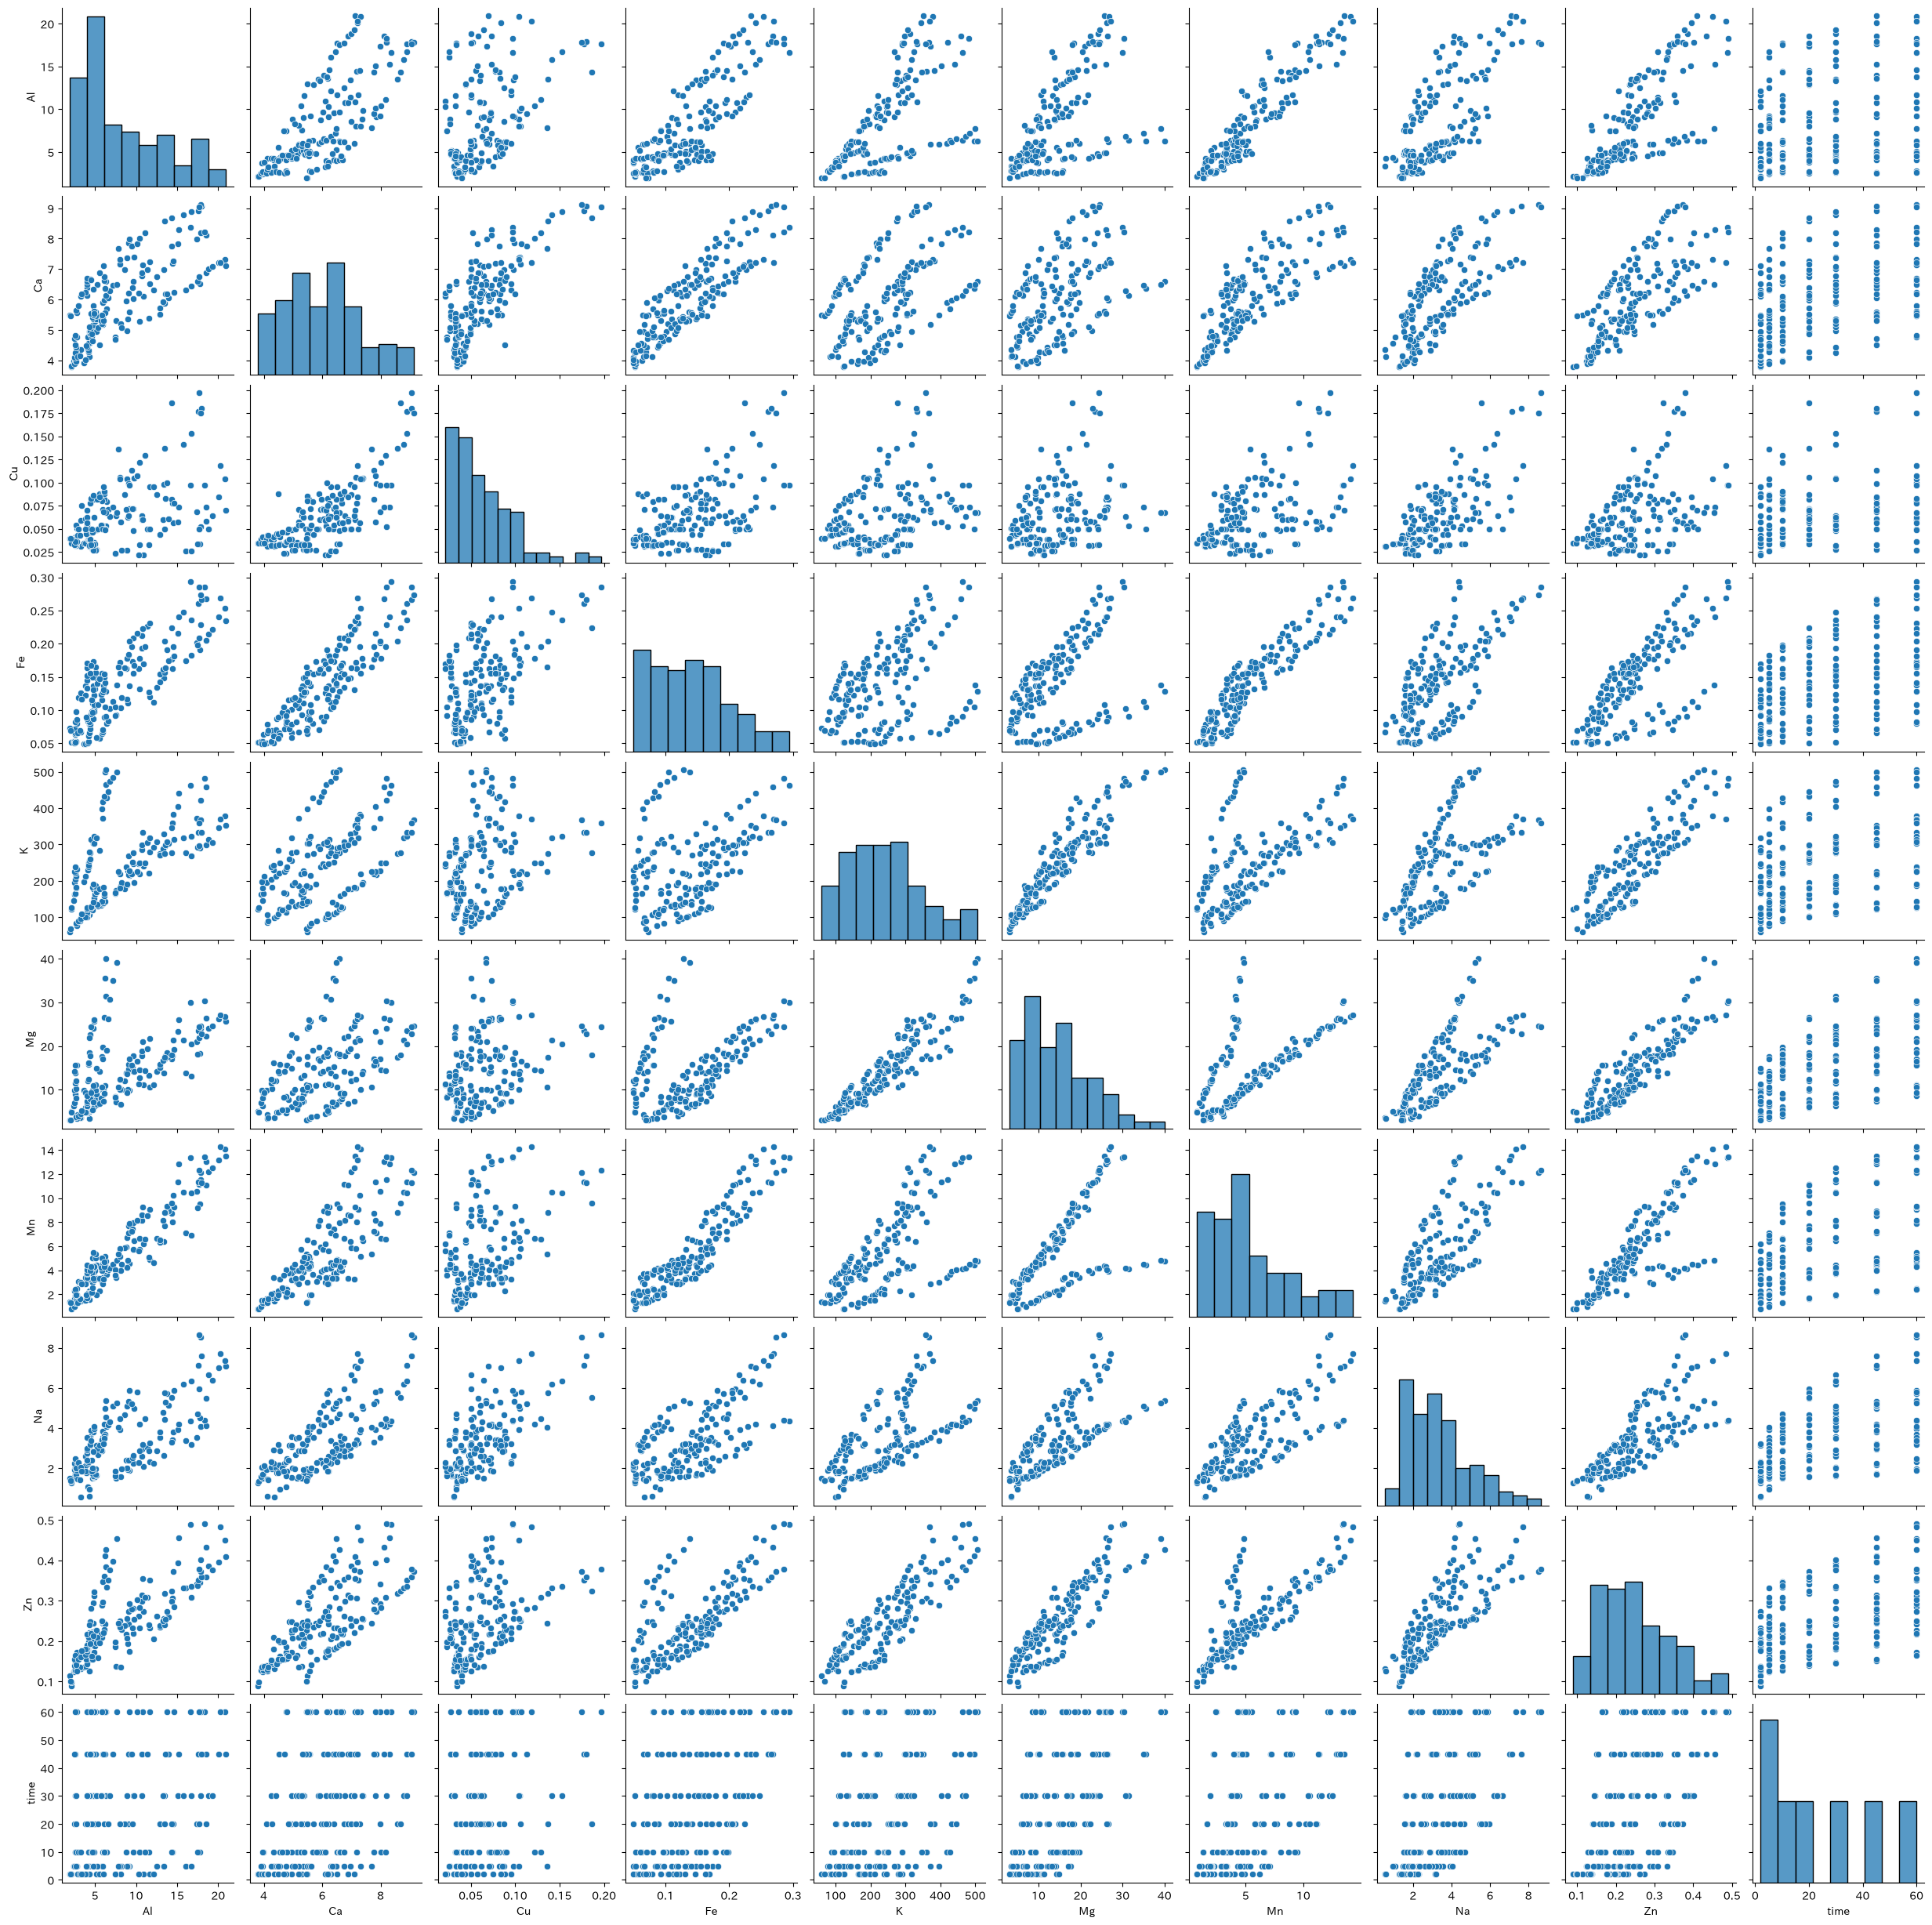

In [5]:
#　ペアプロットによる各変数間の二次元空間像
sns.pairplot(df)
plt.show()

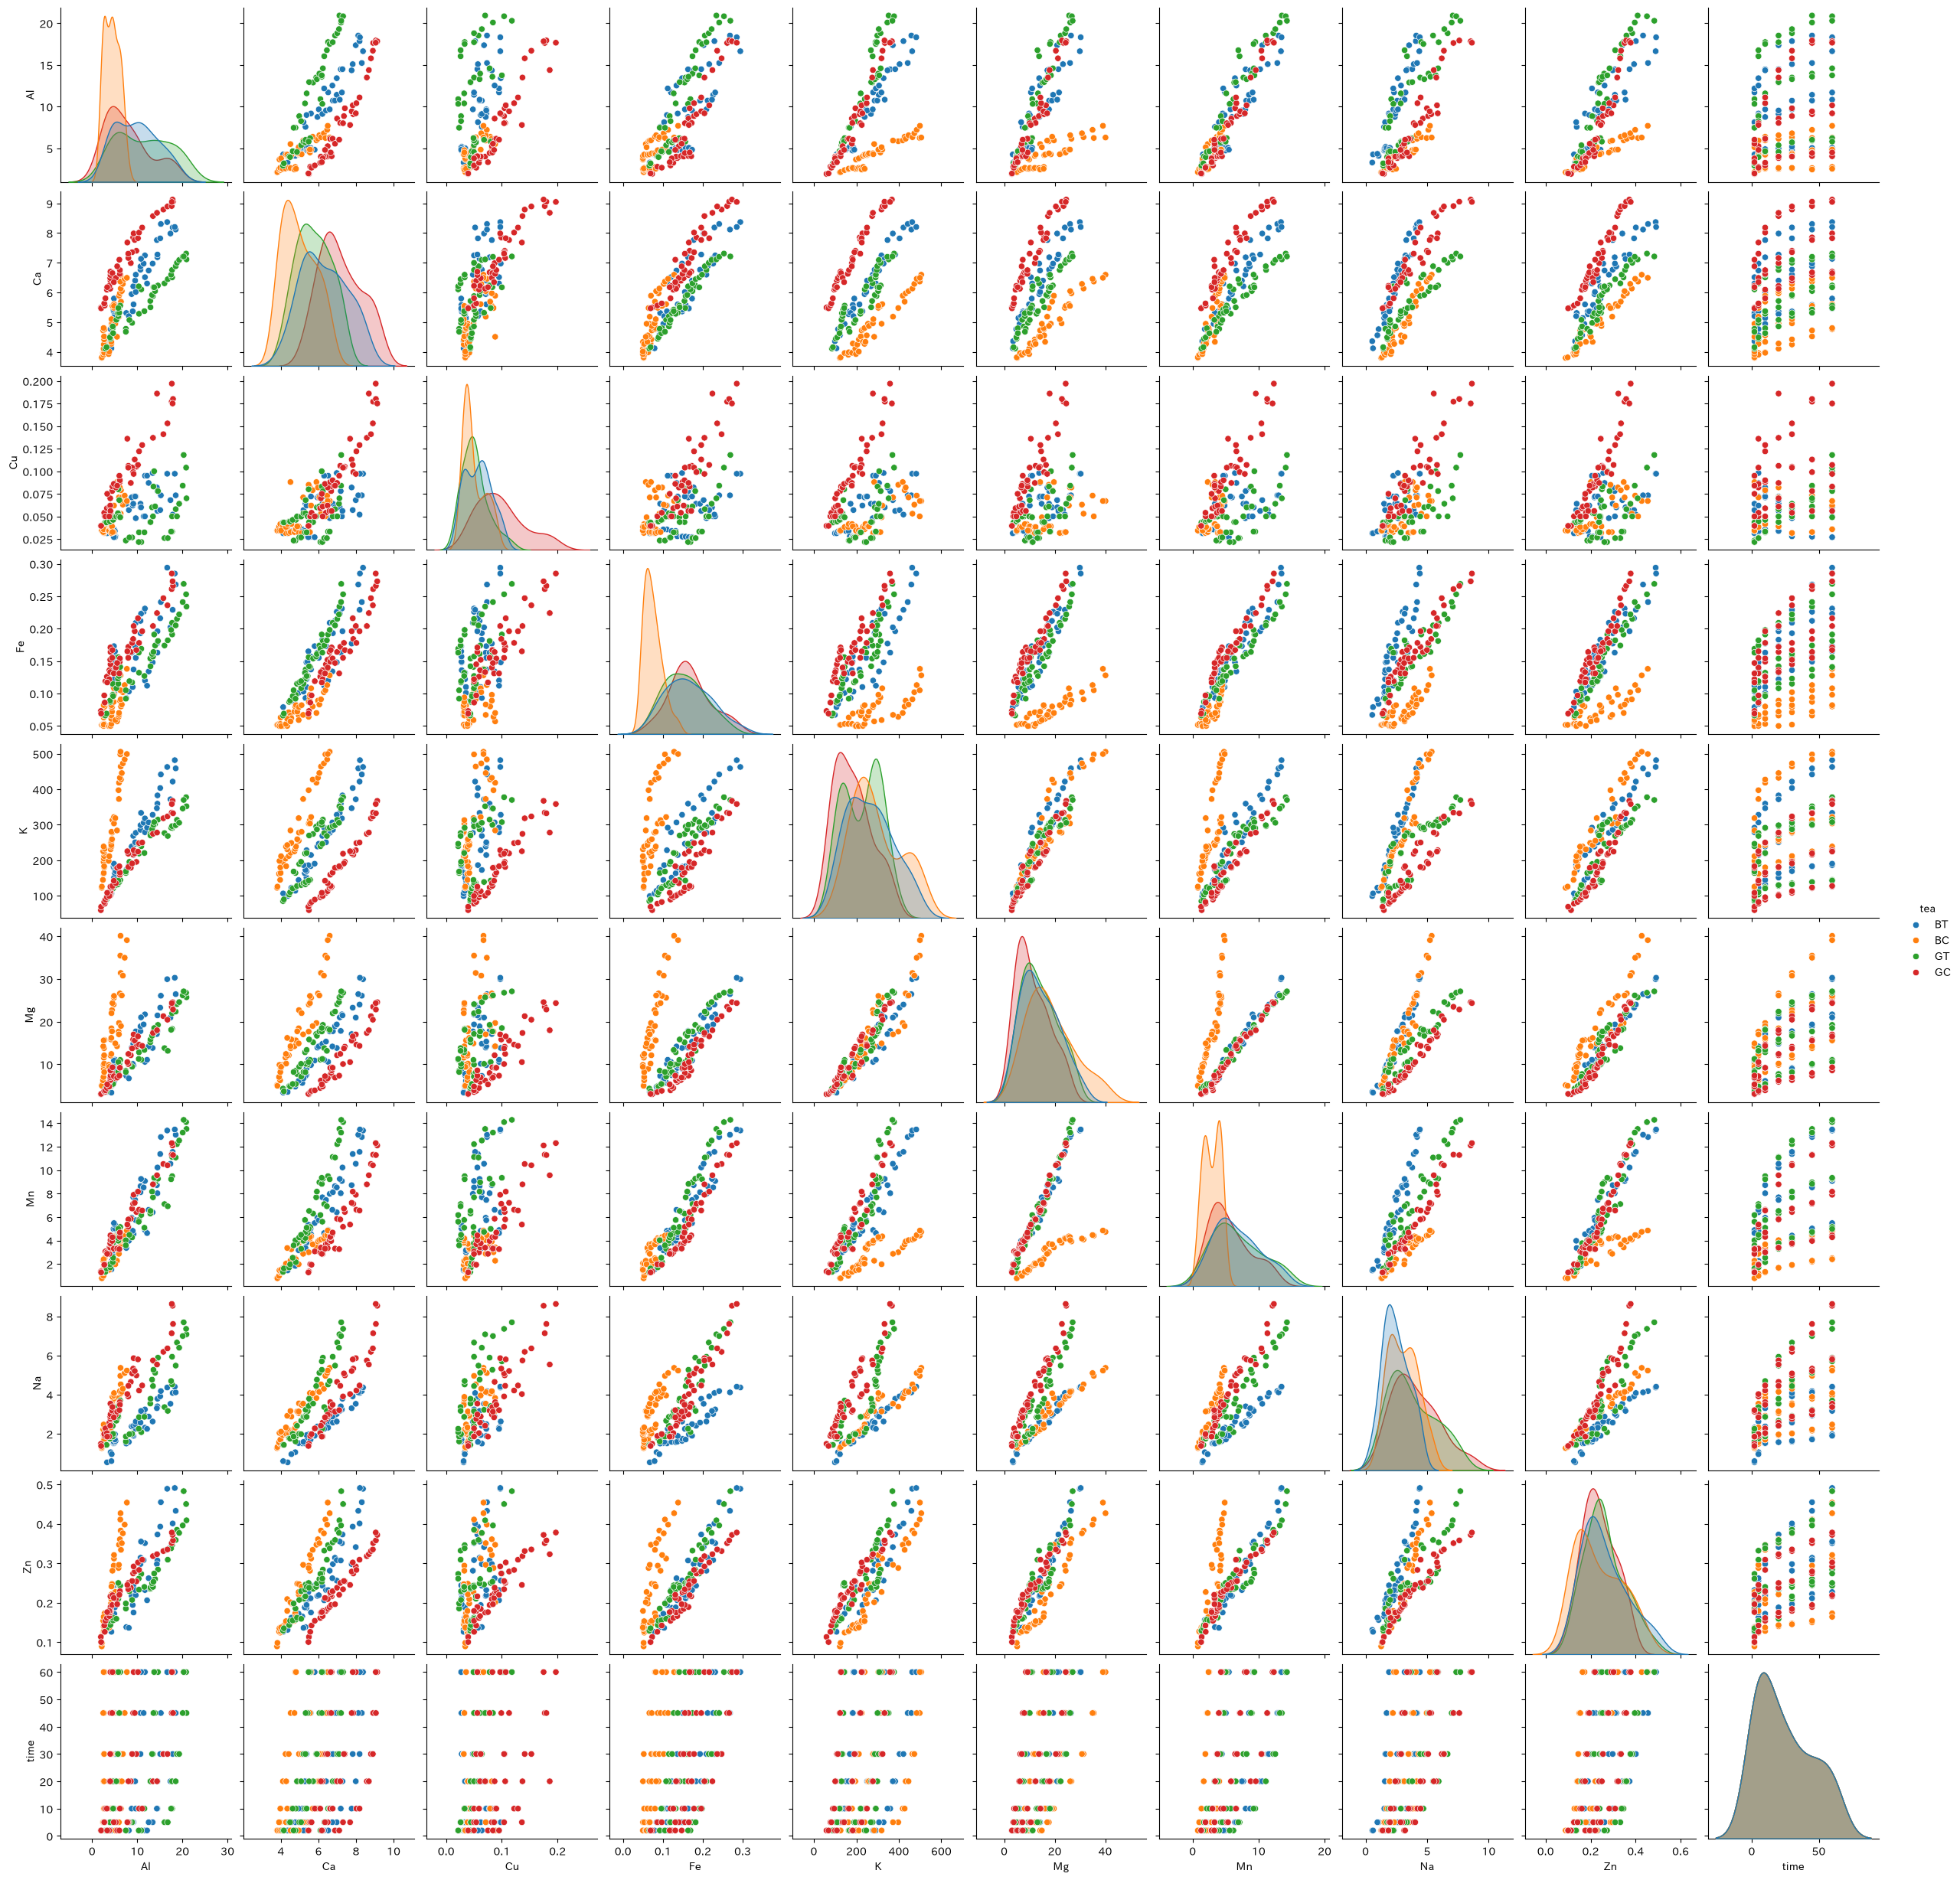

In [6]:
#　ペアプロットによる各変数間の二次元空間像（その２）：茶の品種で色分け
sns.pairplot(df,hue='tea')
plt.show()

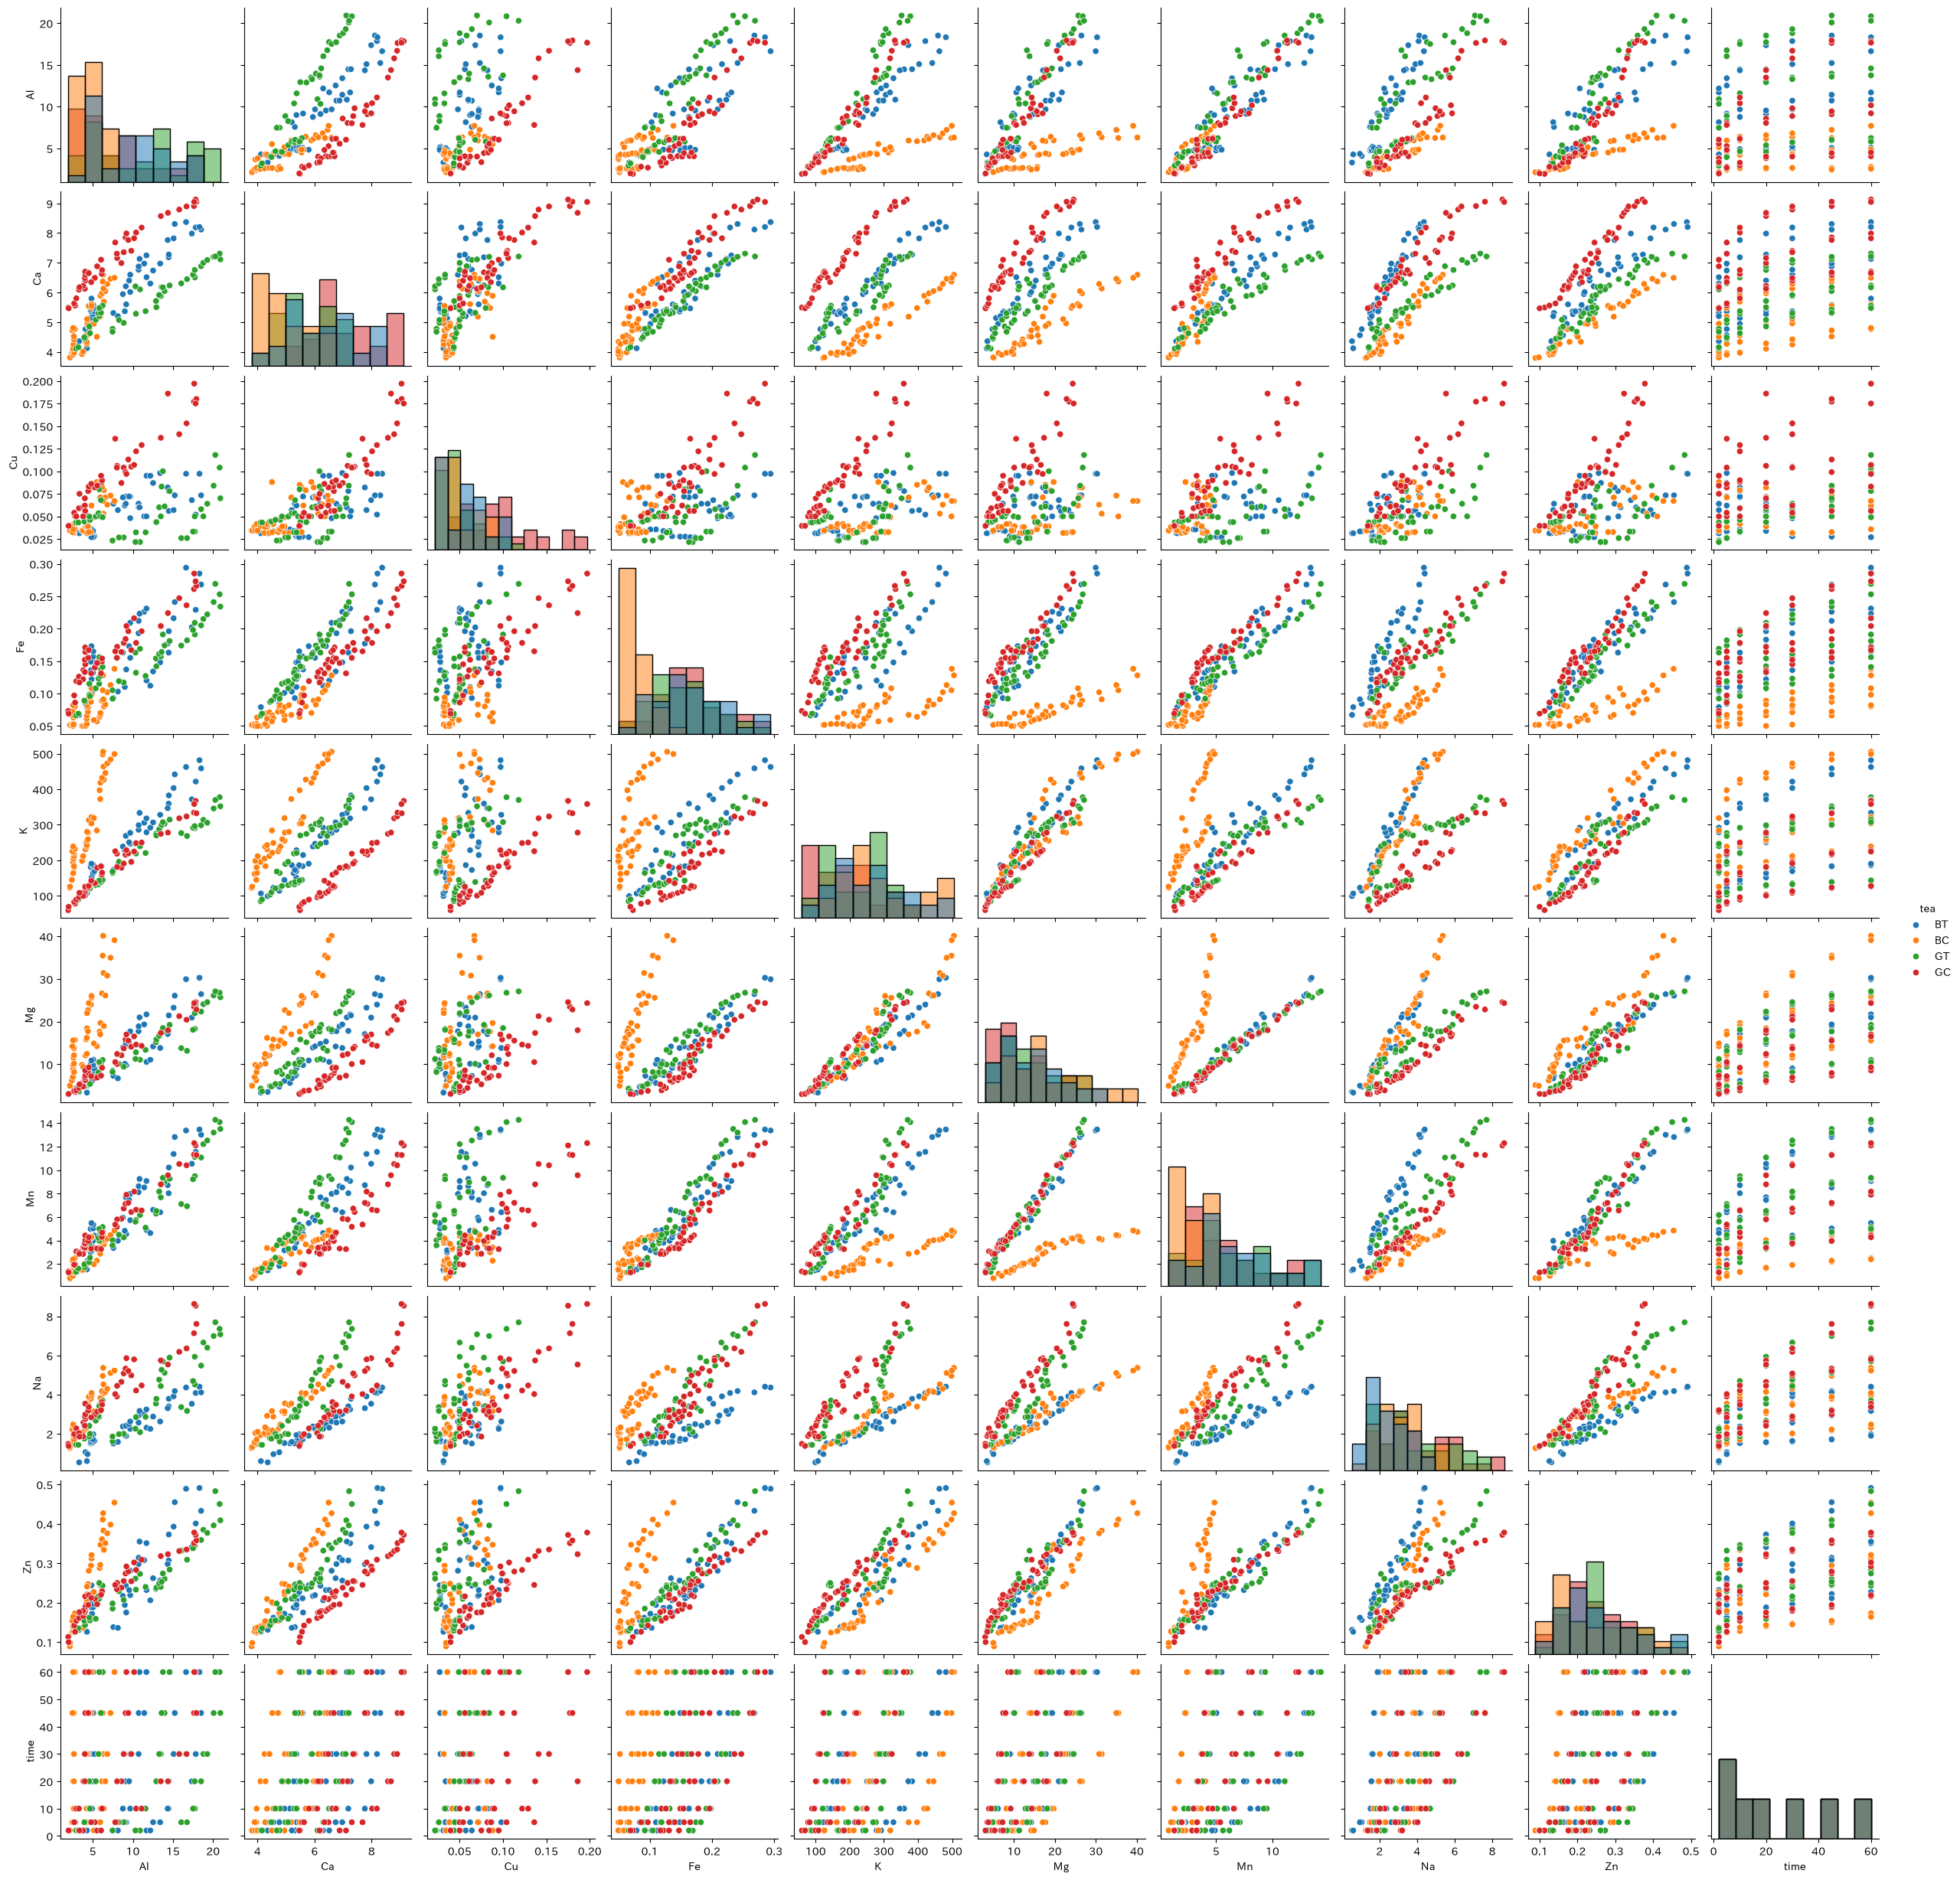

In [7]:
#　ペアプロットによる各変数間の二次元空間像（その３）：対角成分をヒストグラムに変更
sns.pairplot(df,hue='tea',diag_kind='hist')
plt.show()

# 3. 機械学習モデルの比較

### データセットの指定
9つの元素分析値に加え、抽出条件である**抽出濃度（`Concentration`）**・**抽出時間（`time`）**も説明変数に加えます。`Concentration`は`'1%'`のような文字列なので、`%`を取り除いて数値（1.0, 2.0, 3.0）に変換してから使います。目的変数は引き続き茶の品種（`tea`列）です。

In [8]:
# 説明変数と目的変数を用意しましょう

# Concentration列（'1%'などの文字列）を数値に変換
df['Concentration_num'] = df['Concentration'].str.rstrip('%').astype(float)

X = df.drop(['tea', 'Concentration'], axis=1)  # 元素分析値9列 + Concentration_num + time = 11列
y = df['tea']                                    # 茶の品種（ラベル）

In [9]:
X

,Al,Ca,Cu,Fe,K,Mg,Mn,Na,Zn,time,Concentration_num
0,3.297,4.356,0.031290,0.067,99.06,3.531,1.455,0.541,0.131,2,1.0
1,4.267,4.118,0.031290,0.079,106.50,3.378,1.542,0.603,0.126,2,1.0
2,4.088,4.763,0.033370,0.084,114.00,4.763,1.838,1.058,0.156,5,1.0
3,4.338,4.556,0.033370,0.091,122.60,5.005,2.269,0.958,0.162,5,1.0
4,4.732,5.138,0.035514,0.110,132.40,5.626,2.998,1.510,0.165,10,1.0
...,...,...,...,...,...,...,...,...,...,...,...
163,16.690,8.895,0.153000,0.236,323.40,20.450,10.420,6.360,0.335,30,3.0
164,17.620,8.909,0.177000,0.261,334.20,23.486,11.330,7.133,0.351,45,3.0
165,17.920,9.056,0.180000,0.266,332.30,22.840,11.290,7.609,0.358,45,3.0
166,17.820,9.128,0.175000,0.273,367.30,24.560,12.110,8.537,0.372,60,3.0


In [10]:
y

0      BT
1      BT
2      BT
3      BT
4      BT
       ..
163    GC
164    GC
165    GC
166    GC
167    GC
Name: tea, Length: 168, dtype: str

### データセットの分割（Data set splitting）
機械学習モデルの性能を正確に評価するためには、モデルを学習させる**訓練データ**と、学習済みのモデルの性能を評価するための**テストデータ**にデータを分割する必要があります。scikit-learnの`train_test_split()`関数を使用すると、この分割を簡単に実行できます。

**訓練データ（Training Data）**：　機械学習モデルの訓練に使用されるデータセットです。モデルは、訓練データを分析してパターンや関連性を学習し、未知のデータに対して予測を行うための知識を獲得します。

**テストデータ（Test Data）**：モデルの訓練後に性能を評価するために使用されるデータセットです。テストデータは、訓練データとは異なるデータでなければなりません。

> **標準化のタイミングに関する注意：** 標準化（`StandardScaler`）は、訓練データとテストデータに分割した**あと**、訓練データだけを使って基準（平均・標準偏差）を計算し、その基準をテストデータにも適用します。分割する前にデータ全体で標準化すると、本来モデルが見てはいけないテストデータの情報が学習時に間接的に漏れる**データリーケージ**が起こります（回帰予測編で詳しく説明した内容と同じです）。以下では、先に分割してから標準化する、正しい順序で実装します。

In [11]:
#データセットの分割のライブラリの読み込み
from sklearn.model_selection import train_test_split

# train_test_split関数によるデータセット分割
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size = 0.2,   # 20%をテストデータとするデータ分割
                                                    stratify = y,      # ４つの品種について均等分割
                                                    random_state=42
                                                    )  

`stratify=y`を指定すると、訓練データ・テストデータのどちらでも4つの品種の比率がほぼ均等になるように分割されます。品種ごとの件数に偏りがあるデータで`stratify`を指定しないと、テストデータにある品種がほとんど含まれない、といった事態が起こり得ます。

### 標準化
モデルはデータのスケールに敏感であるため、標準化が重要です。特にサポートベクターマシン（SVM）などのアルゴリズムでは、特徴量のスケールが異なると結果に大きく影響します。標準化では、各特徴量を平均0、標準偏差1にスケーリングし、異なるスケールを持つ特徴量を均等に扱えるようにします。

**訓練データで`fit`し、その基準を訓練データ・テストデータの両方に`transform`で適用します。**

In [12]:
from sklearn.preprocessing import StandardScaler

# 標準化（訓練データだけでfitし、train/test両方にtransformを適用）
scaler = StandardScaler()
scaler.fit(X_train)

X_train = pd.DataFrame(scaler.transform(X_train), columns=X.columns, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=X.columns, index=X_test.index)

In [13]:
X_train

,Al,Ca,Cu,Fe,K,Mg,Mn,Na,Zn,time,Concentration_num
145,-0.477968,0.520678,0.760611,0.215528,-0.758321,-0.679458,-0.268759,0.090478,-0.238555,-0.665730,-0.063518
79,-0.353683,0.161941,-0.036670,-0.648910,2.187541,2.144176,-0.420368,0.609516,1.372754,0.340562,1.152405
37,1.760324,1.629290,-0.361489,1.462312,1.697043,1.257945,1.767903,0.470385,1.646786,0.340562,1.152405
29,0.674500,0.172742,0.908256,-0.482672,0.454512,-0.435581,-0.281491,-0.693479,-0.490665,-1.068246,1.152405
7,-0.694176,-0.623422,-0.898467,-0.150196,-0.776523,-0.864035,-0.474853,-1.126117,-0.687968,-0.162584,-1.279441
...,...,...,...,...,...,...,...,...,...,...,...
112,0.429375,0.019989,-1.259168,0.464884,-0.047482,-0.432439,0.174226,-0.800209,0.243741,-1.068246,1.152405
96,-0.464563,-0.402009,-0.450075,-0.000582,-0.956628,-0.439901,-0.128105,0.227067,-0.085097,1.850000,-1.279441
151,0.149972,1.303727,1.439777,0.913727,-0.240041,0.153102,0.482479,1.185095,0.309509,1.095281,-0.063518
102,0.331708,-0.613393,-0.942224,-0.150196,-0.244831,-0.205580,0.049266,-0.312936,-0.194710,-0.665730,-0.063518


In [14]:
y_train

145    GC
79     BC
37     BT
29     BT
7      BT
       ..
112    GT
96     GT
151    GC
102    GT
129    GC
Name: tea, Length: 134, dtype: str

### scikit-learnによる分類モデルの選択

scikit-learnは、機械学習のアルゴリズムをPythonで実装するためのライブラリです。特に、分類問題においては、ロジスティック回帰、k近傍法、サポートベクターマシン、決定木、ランダムフォレスト、ニューラルネットワークなど、様々なアルゴリズムが提供されています。どのモデルを選ぶべきかは、**データの特性**（線形か非線形か、データの量、ノイズの有無など）や、**タスクの要件**（精度、解釈性、計算時間など）によって異なります。

**主な分類モデルの特徴**

* **ロジスティック回帰:**
  - 線形モデルの一種で、入力データからクラスの所属確率を予測します。
  - データが線形に分離可能な場合や、特徴量の重要度を把握したい場合に適しています。
* **k近傍法:**
  - 新しいデータ点に対して、最も近いk個のデータ点のラベルを参照して、そのデータ点のラベルを決定します。
  - データが局所的な構造を持つ場合や、非線形な境界を持つ場合に有効です。
* **サポートベクターマシン:**
  - データを最もよく分離する超平面（決定境界）を見つけ、新しいデータを分類します。
  - マージン最大化という概念に基づいており、一般化性能が高いことが期待できます。
* **決定木:**
  - データを順次分割していくことで、決定規則を樹形図で表現するモデルです。
  - 非線形な関係を捉えることができ、解釈性が高い点が特徴です。
* **ランダムフォレスト:**
  - 複数の決定木を組み合わせることで、過学習を防ぎ、汎化性能を向上させたモデルです。
  - さまざまな種類のデータに対して高い精度を発揮します。
* **ニューラルネットワーク:**
  - 人間の脳神経回路を模倣したモデルで、複雑なパターンを学習することができます。
  - 大規模なデータセットや画像認識、自然言語処理など、高度なタスクに適用されます。

**モデル選択のポイント**

* **データの探索:** データの分布、特徴量間の関係、外れ値などを可視化し、データの特性を把握します。
* **アルゴリズムの特性:** 各アルゴリズムの強みと弱みを理解し、データの特性に合ったアルゴリズムを選びます。
* **ハイパーパラメータチューニング:** アルゴリズムのパラメータを調整することで、モデルの性能を向上させることができます。
* **交差検証:** モデルの汎化性能を評価するために、交差検証を行います。

ここでは決定木、ランダムフォレスト、サポートベクターマシンの3つのモデルについて検討します（ロジスティック回帰・k近傍法・ニューラルネットワークは、上記の紹介にとどめ、本ノートブックでは実装しません）。再現性のため、乱数を使うモデル（決定木・ランダムフォレスト）には`random_state=42`を指定します。

## 1. 決定木
決定木は、データの属性値を基に、一連のif-thenルールを適用することで、目的変数を予測する非線形モデルです。

### ①　モデル構築
DecisionTreeClassifier クラスは、Scikit-learnライブラリが提供するクラスで、分類型による決定木モデルを構築するために使用されます。

In [15]:
# 決定木法のインポート（クラス指定）
from sklearn.tree import DecisionTreeClassifier

# 決定木法によるモデル構築（トレーニング）
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)   

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

#### ②　モデルの評価：正解率の計算
#### 訓練データ

In [16]:
#訓練データの予測ラベル
y_pred_train = model.predict(X_train)

In [17]:
# 訓練データの正解率
accuracy_train_tree = model.score(X_train, y_train)
print('訓練データ正解率:{:.3f}'.format(accuracy_train_tree))

訓練データ正解率:1.000


#### テストデータ

In [18]:
#テストデータの予測ラベル
y_pred_test = model.predict(X_test)

In [19]:
# テストデータの正解率
accuracy_test_tree = model.score(X_test, y_test)
print('テストデータ正解率:{:.3f}'.format(accuracy_test_tree))

テストデータ正解率:0.853


### ③　混同行列（Confusion Matrix）

混同行列は、機械学習の分類問題において、モデルの性能を評価するために用いられる指標です。特に、不均衡データ（あるクラスのデータが圧倒的に多いデータセット）や、コスト感度の高い誤分類（ある種類の誤分類が他の種類よりも重大な場合）を扱う際に、これらの指標は非常に有効です。

> **本データセットは4クラス分類です。** 混同行列は「予測結果と実際のラベルを表にまとめたもの」で、2クラス分類なら2×2の表になりますが、本データセットのように**4品種（BC・BT・GC・GT）を分類する場合は4×4の表**になります。対角成分（左上から右下）が正しく分類できた件数、それ以外の成分がどの品種をどの品種と間違えたかを示します。

混同行列から、正解率だけでなく、品種ごとの**適合率（Precision）**・**再現率（Recall）**・**F1スコア**も計算できます。それぞれの意味は次の通りです。

* **適合率（Precision）**: ある品種と予測したデータのうち、実際にその品種だった割合。
* **再現率（Recall）**: 実際にその品種であるデータのうち、正しくその品種と予測できた割合。
* **F1スコア**: 適合率と再現率の調和平均。

#### 訓練データ

**混同行列の算出　その１**  
sklearn.metrics モジュールにある混同行列を計算するための関数`confusion_matrix`を用いる方法です。**第一引数に正解ラベル（`y_true`）、第二引数に予測ラベル（`y_pred`）を渡すのがscikit-learnの規約**です。この順序を守ることで、他の関数（後述の`classification_report`など）とも一貫した解釈ができます。

In [20]:
# scikit-learnのconfusion_matrixを使った混同行列の表記方法
# 第一引数=正解ラベル(y_train)、第二引数=予測ラベル(y_pred_train) の順序に注意

from sklearn import metrics
print(metrics.confusion_matrix(y_train, y_pred_train))

[[33  0  0  0]
 [ 0 34  0  0]
 [ 0  0 33  0]
 [ 0  0  0 34]]


**混同行列の算出　その2**  
Pandasライブラリの`crosstab`関数を使用して、混同行列を作成します。ここでも、第一引数に正解ラベル、第二引数に予測ラベルを渡します。

In [21]:
# pandasのcrosstabを使った混同行列の別の表記方法
# 第一引数=正解ラベル、第二引数=予測ラベル

pd.crosstab(y_train, y_pred_train, rownames=['実際'], colnames=['予測'], margins = True) 

予測,BC,BT,GC,GT,All
実際,,,,,
BC,33,0,0,0,33
BT,0,34,0,0,34
GC,0,0,33,0,33
GT,0,0,0,34,34
All,33,34,33,34,134


#### テストデータ

In [22]:
# pandasのcrosstabを使った混同行列の別の表記方法

pd.crosstab(y_test, y_pred_test, rownames=['実際'], colnames=['予測'], margins = True) 

予測,BC,BT,GC,GT,All
実際,,,,,
BC,9,0,0,0,9
BT,2,6,0,0,8
GC,0,0,9,0,9
GT,1,1,1,5,8
All,12,7,10,5,34


In [23]:
print(metrics.confusion_matrix(y_test, y_pred_test))

[[9 0 0 0]
 [2 6 0 0]
 [0 0 9 0]
 [1 1 1 5]]


**適合率・再現率・F1スコアの一覧表示：** `classification_report`を使うと、品種ごとの適合率・再現率・F1スコアをまとめて確認できます。

In [24]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

          BC       0.75      1.00      0.86         9
          BT       0.86      0.75      0.80         8
          GC       0.90      1.00      0.95         9
          GT       1.00      0.62      0.77         8

    accuracy                           0.85        34
   macro avg       0.88      0.84      0.84        34
weighted avg       0.87      0.85      0.85        34



## 2. ランダムフォレスト
RandomForestClassifier クラスは、Scikit-learnライブラリが提供するクラスで、分類型によるランダムフォレストモデルを構築するために使用されます。

#### ①モデル構築

In [25]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)   

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

### ②　モデルの評価：正解率・混同行列
#### 訓練データ

In [26]:
y_pred_train = model.predict(X_train)

In [27]:
accuracy_train_rf = model.score(X_train, y_train)
print("RandomForestClassifier training score : {:.3f}".format(accuracy_train_rf))
pd.crosstab(y_train, y_pred_train, rownames=['実際'], colnames=['予測'], margins = True) 

RandomForestClassifier training score : 1.000


予測,BC,BT,GC,GT,All
実際,,,,,
BC,33,0,0,0,33
BT,0,34,0,0,34
GC,0,0,33,0,33
GT,0,0,0,34,34
All,33,34,33,34,134


#### テストデータ

In [28]:
y_pred_test = model.predict(X_test)  

In [29]:
accuracy_test_rf = model.score(X_test, y_test)
print("RandomForestClassifier test score : {:.3f}".format(accuracy_test_rf))
pd.crosstab(y_test, y_pred_test, rownames=['実際'], colnames=['予測'], margins = True) 

RandomForestClassifier test score : 1.000


予測,BC,BT,GC,GT,All
実際,,,,,
BC,9,0,0,0,9
BT,0,8,0,0,8
GC,0,0,9,0,9
GT,0,0,0,8,8
All,9,8,9,8,34


In [30]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

          BC       1.00      1.00      1.00         9
          BT       1.00      1.00      1.00         8
          GC       1.00      1.00      1.00         9
          GT       1.00      1.00      1.00         8

    accuracy                           1.00        34
   macro avg       1.00      1.00      1.00        34
weighted avg       1.00      1.00      1.00        34



## 3.サポートベクターマシン

SVC クラスは、Scikit-learnライブラリが提供するクラスで、分類型によるサポートベクターマシンモデルを構築するために使用されます。

### ① モデル構築

In [31]:
# サポートベクター
from sklearn.svm import SVC

model = SVC()
model.fit(X_train, y_train)   

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide <shrinking_svm>`.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide <scores_probabilities>`...deprecated:: 1.9 The `probability` parameter is deprecated and will be removed in 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`.",'deprecated'
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


### ②　モデルの評価：正解率・混同行列
#### 訓練データ

In [32]:
y_pred_train = model.predict(X_train)

In [33]:
accuracy_train_svc = model.score(X_train, y_train)
print("SupportVectorClassifier training score : {:.3f}".format(accuracy_train_svc))
pd.crosstab(y_train, y_pred_train, rownames=['実際'], colnames=['予測'], margins = True) 

SupportVectorClassifier training score : 0.970


予測,BC,BT,GC,GT,All
実際,,,,,
BC,33,0,0,0,33
BT,1,33,0,0,34
GC,0,0,33,0,33
GT,1,2,0,31,34
All,35,35,33,31,134


#### テストデータ

In [34]:
y_pred_test = model.predict(X_test)

In [35]:
accuracy_test_svc = model.score(X_test, y_test)
print("SupportVectorClassifier test score : {:.3f}".format(accuracy_test_svc))
pd.crosstab(y_test, y_pred_test, rownames=['実際'], colnames=['予測'], margins = True) 

SupportVectorClassifier test score : 0.912


予測,BC,BT,GC,GT,All
実際,,,,,
BC,9,0,0,0,9
BT,0,8,0,0,8
GC,0,0,9,0,9
GT,1,2,0,5,8
All,10,10,9,5,34


In [36]:
print(classification_report(y_test, y_pred_test))

              precision    recall  f1-score   support

          BC       0.90      1.00      0.95         9
          BT       0.80      1.00      0.89         8
          GC       1.00      1.00      1.00         9
          GT       1.00      0.62      0.77         8

    accuracy                           0.91        34
   macro avg       0.93      0.91      0.90        34
weighted avg       0.93      0.91      0.91        34



## 4. 3モデルの比較

決定木・ランダムフォレスト・サポートベクターマシンの正解率を一覧表と図で比較しましょう（回帰予測編と同じ考え方です）。

In [37]:
comparison = pd.DataFrame({
    '訓練データ正解率': [accuracy_train_tree, accuracy_train_rf, accuracy_train_svc],
    'テストデータ正解率': [accuracy_test_tree, accuracy_test_rf, accuracy_test_svc],
}, index=['決定木', 'ランダムフォレスト', 'SVM'])

comparison['差（訓練－テスト）'] = comparison['訓練データ正解率'] - comparison['テストデータ正解率']
comparison

,訓練データ正解率,テストデータ正解率,差（訓練－テスト）
決定木,1.000000,0.852941,0.147059
ランダムフォレスト,1.000000,1.000000,0.000000
SVM,0.970149,0.911765,0.058385


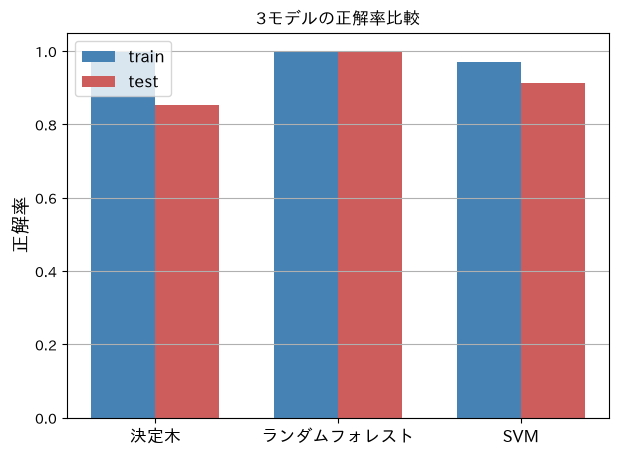

In [38]:
fig, ax = plt.subplots(figsize=(7,5))

x = np.arange(len(comparison.index))
width = 0.35

ax.bar(x - width/2, comparison['訓練データ正解率'], width, label='train', color='steelblue')
ax.bar(x + width/2, comparison['テストデータ正解率'], width, label='test', color='indianred')

ax.set_xticks(x)
ax.set_xticklabels(comparison.index, fontsize=12)
ax.set_ylabel('正解率', fontsize=14)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=12)
ax.grid(axis='y')
plt.title('3モデルの正解率比較')
plt.show()

決定木は訓練データで100%の正解率になりやすい一方、テストデータでは訓練データより下がる傾向があります（過学習）。ランダムフォレストは複数の決定木を組み合わせることで、通常はテストデータでも決定木単体より安定した性能を示します。SVMは標準化された特徴量に対してマージン最大化を行うため、本データセットのように特徴量間のスケール差が大きい場合に効果を発揮しやすい手法です。

---

# 5. まとめと演習問題

## まとめ

本ノートブックでは、次のことを学びました。

* 教師あり学習による4クラス分類（決定木・ランダムフォレスト・SVM）の構築と評価
* `stratify=y`を使った、クラス比率を保った訓練/テスト分割
* 標準化はテストデータの情報が漏れないよう、訓練データだけで`fit`すること
* 混同行列は`confusion_matrix(y_true, y_pred)`の順序で呼び出すのがscikit-learnの規約であること、4クラス分類では4×4の表になること
* `classification_report`による、品種ごとの適合率・再現率・F1スコアの確認
* 3モデルの正解率を一覧表・棒グラフで比較する方法

## 本ノートブックでは扱っていないこと（今後の課題）

1. **ロジスティック回帰・k近傍法・ニューラルネットワークは実装していません。** 「モデル選択」で特徴を紹介したのみです。
2. **ハイパーパラメータの調整（グリッドサーチ等）は行っていません。**
3. **k-foldクロスバリデーションは行っていません。** 168件と比較的多いデータですが、1回の分割による評価には`Scikit-learn-4_ML.ipynb`で示した通り一定の不確実性が伴います。

## 演習問題

1. `classification_report`の結果を見て、3モデルのうちどのモデルが、どの品種の分類にもっとも苦労しているか確認してみましょう。
2. ロジスティック回帰（`sklearn.linear_model.LogisticRegression`）を実装し、決定木・ランダムフォレスト・SVMと正解率を比較してみましょう。
3. `DecisionTreeClassifier`の`max_depth`パラメータ（例：`max_depth=3`）を指定して木の深さを制限し、訓練データとテストデータの正解率の差がどう変わるか確認してみましょう。